In [1]:
import pandas as pd
import numpy as np
import pickle, json, time, logging
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 2.1 MB/s eta 0:00:00


In [4]:
# Groq client
try:
    from groq import Groq
    GROQ_AVAILABLE = True
except ImportError:
    GROQ_AVAILABLE = False
    print('Groq not installed. Run: pip install groq')

# Logger — for internal tracking only, never shown to faculty
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger('failsafe.intervention')

In [ ]:
# ── Groq config ──────────────────────────────────────────────
GROQ_API_KEY   = 'groq-apikey'   # replace with your key
GROQ_MODEL     = 'llama-3.3-70b-versatile'  # best quality on Groq
GROQ_FALLBACK  = 'llama-3.1-8b-instant'     # faster fallback model
GROQ_MAX_TOKENS = 500
GROQ_TIMEOUT    = 8      # seconds — if no response in 8s, use rules
GROQ_RETRIES    = 1      # retry once before falling back to rules

# ── Load model artifacts ──────────────────────────────────────
with open('failsafe_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)

with open('threshold_config.json') as f:
    thresh_config = json.load(f)

with open('features.json') as f:
    FEATURES = json.load(f)

DECISION_THRESHOLD = thresh_config['decision_threshold']
RISK_LOW           = thresh_config['risk_low_threshold']
RISK_HIGH          = thresh_config['risk_high_threshold']

print('Config loaded!')
print(f'Groq model  : {GROQ_MODEL}')
print(f'Timeout     : {GROQ_TIMEOUT}s')
print(f'Retries     : {GROQ_RETRIES}')
print(f'Fallback    : rule-based (silent)')

Config loaded!
Groq model  : llama-3.3-70b-versatile
Timeout     : 8s
Retries     : 1
Fallback    : rule-based (silent)


In [7]:
INTERVENTION_RULES = {
    'absences'  : {'bad_when': 'high', 'threshold': 6,  'priority': 1, 'category': 'Attendance',
                   'intervention': 'Student has high absences. Schedule an immediate one-on-one attendance review with the class advisor. Identify whether absences are health-related, family-related, or motivational. Issue a formal attendance warning if absences exceed 10.'},

    'failures'  : {'bad_when': 'high', 'threshold': 1,  'priority': 1, 'category': 'Academic History',
                   'intervention': 'Student has a history of past failures. Assign a dedicated academic mentor for weekly check-ins. Enroll student in remedial support classes. Set up monthly progress reviews with the HOD.'},

    'G2'        : {'bad_when': 'low',  'threshold': 10, 'priority': 1, 'category': 'Academic Performance',
                   'intervention': 'Student scored below passing in the second period. Provide targeted tutoring sessions before the final exam. Review second period papers with the student to identify weak topics.'},

    'G1'        : {'bad_when': 'low',  'threshold': 10, 'priority': 2, 'category': 'Academic Performance',
                   'intervention': 'Student showed early signs of struggle in the first period. Conduct a diagnostic assessment to identify knowledge gaps. Pair with a higher-performing peer for study support.'},

    'studytime' : {'bad_when': 'low',  'threshold': 2,  'priority': 2, 'category': 'Study Habits',
                   'intervention': 'Student reports very low weekly study time. Introduce a structured study timetable with the class advisor. Recommend the institution study skills workshop.'},

    'Dalc'      : {'bad_when': 'high', 'threshold': 3,  'priority': 1, 'category': 'Wellness',
                   'intervention': 'Student has high weekday alcohol consumption. Refer to the student counselling or wellness center immediately. Coordinate with the guardian if appropriate.'},

    'Walc'      : {'bad_when': 'high', 'threshold': 3,  'priority': 2, 'category': 'Wellness',
                   'intervention': 'Student has elevated weekend alcohol consumption. Suggest a confidential wellness session. Monitor for impacts on Monday attendance.'},

    'goout'     : {'bad_when': 'high', 'threshold': 4,  'priority': 2, 'category': 'Time Management',
                   'intervention': 'Student spends significant time going out. Discuss time management strategies. Help create a balanced weekly schedule combining social and study time.'},

    'health'    : {'bad_when': 'low',  'threshold': 2,  'priority': 2, 'category': 'Health Support',
                   'intervention': 'Student reports poor health status. Refer to the campus health center. Explore whether academic accommodations are needed.'},

    'higher'    : {'bad_when': 'low',  'threshold': 1,  'priority': 2, 'category': 'Motivation',
                   'intervention': 'Student does not aspire to higher education. Schedule a career counselling session. Connect with alumni or industry mentors to inspire motivation.'},

    'internet'  : {'bad_when': 'low',  'threshold': 1,  'priority': 3, 'category': 'Resource Access',
                   'intervention': 'Student lacks internet at home. Ensure awareness of on-campus Wi-Fi and computer labs. Provide printed study materials where possible.'},

    'Medu'      : {'bad_when': 'low',  'threshold': 2,  'priority': 3, 'category': 'Family Background',
                   'intervention': 'Student comes from a low parental education background. Provide additional academic guidance. Connect with first-generation student support groups.'},

    'Fedu'      : {'bad_when': 'low',  'threshold': 2,  'priority': 3, 'category': 'Family Background',
                   'intervention': 'Father has low education level. Ensure access to faculty office hours. Recommend peer tutoring programs.'},

    'famrel'    : {'bad_when': 'low',  'threshold': 2,  'priority': 2, 'category': 'Family & Wellbeing',
                   'intervention': 'Student reports poor family relationship quality. Refer to a student counsellor for emotional support. Monitor for signs of stress or disengagement.'},

    'schoolsup' : {'bad_when': 'low',  'threshold': 1,  'priority': 2, 'category': 'Academic Support',
                   'intervention': 'Student is not receiving school support. Enroll in the academic support program. Assign a subject teacher for additional sessions.'},

    'famsup'    : {'bad_when': 'low',  'threshold': 1,  'priority': 3, 'category': 'Family Support',
                   'intervention': 'Student lacks family educational support. Increase faculty check-ins. Share progress updates with guardians.'},

    'romantic'  : {'bad_when': 'high', 'threshold': 1,  'priority': 3, 'category': 'Personal Factors',
                   'intervention': 'Student is in a romantic relationship which may affect focus. Counsel sensitively on balancing personal and academic life.'},

    'traveltime': {'bad_when': 'high', 'threshold': 3,  'priority': 3, 'category': 'Logistics',
                   'intervention': 'Student has a long daily commute. Explore campus accommodation options. Consider scheduling sessions at favorable times.'},

    'freetime'  : {'bad_when': 'high', 'threshold': 4,  'priority': 3, 'category': 'Time Management',
                   'intervention': 'Student reports excessive free time indicating low engagement. Encourage joining academic clubs or project groups.'},

    'paid'      : {'bad_when': 'low',  'threshold': 1,  'priority': 3, 'category': 'Academic Support',
                   'intervention': 'Student is not attending extra classes. Recommend free tutoring or peer study groups on campus.'},

    'activities': {'bad_when': 'low',  'threshold': 1,  'priority': 3, 'category': 'Engagement',
                   'intervention': 'Student is not involved in extracurricular activities. Encourage joining at least one club or sport for engagement.'},
}

print(f'Intervention rules loaded: {len(INTERVENTION_RULES)} features covered.')

Intervention rules loaded: 21 features covered.


In [8]:
def get_risk_band(prob):
    if prob >= RISK_HIGH:
        return 'HIGH'
    elif prob >= RISK_LOW:
        return 'MEDIUM'
    return 'LOW'


def generate_rule_interventions(student_data: dict,
                                 shap_values_dict: dict,
                                 top_n: int = 5) -> list:
    """
    Generate rule-based intervention list from SHAP factors.
    Always succeeds — used as primary structure and as LLM fallback.
    """
    ranked = sorted(shap_values_dict.items(),
                    key=lambda x: abs(x[1]), reverse=True)[:top_n]
    interventions = []

    for feat, shap_val in ranked:
        if feat not in INTERVENTION_RULES:
            continue
        rule      = INTERVENTION_RULES[feat]
        val       = student_data.get(feat)
        if val is None:
            continue
        bad_when  = rule['bad_when']
        threshold = rule['threshold']
        is_risky  = (bad_when == 'high' and val >= threshold) or \
                    (bad_when == 'low'  and val <  threshold)

        if is_risky or abs(shap_val) > 0.2:
            interventions.append({
                'feature'      : feat,
                'value'        : val,
                'shap'         : round(float(shap_val), 4),
                'priority'     : rule['priority'],
                'category'     : rule['category'],
                'intervention' : rule['intervention'],
                'source'       : 'rules',   # track whether LLM or rules generated this
            })

    interventions.sort(key=lambda x: (x['priority'], -abs(x['shap'])))
    return interventions


print('Rule engine defined.')

Rule engine defined.


In [9]:
# Initialize Groq client once — reused across all calls
_groq_client = None

def _get_groq_client():
    """Lazy-initialize Groq client. Returns None if unavailable."""
    global _groq_client
    if _groq_client is not None:
        return _groq_client
    if not GROQ_AVAILABLE or GROQ_API_KEY == 'your_groq_api_key_here':
        return None
    try:
        _groq_client = Groq(api_key=GROQ_API_KEY)
        return _groq_client
    except Exception:
        return None


def _build_prompt(student_data: dict,
                   rule_interventions: list,
                   risk_score: float,
                   risk_band: str) -> str:
    """
    Build the prompt sent to Groq.
    Includes risk score, top risk factors with values, and what the rules suggest.
    """
    factors_text = '\n'.join([
        f"  - {item['category']} ({item['feature']} = {item['value']})"
        for item in rule_interventions
    ])

    rule_text = '\n'.join([
        f"  [{item['category']}]: {item['intervention']}"
        for item in rule_interventions
    ])

    return f"""You are an empathetic educational advisor helping a faculty member support an at-risk student.

Student situation:
- Risk Score: {risk_score}% ({risk_band} risk)
- Key concerns identified:
{factors_text}

Suggested actions from the system:
{rule_text}

Rewrite these as a single, cohesive, empathetic intervention plan for the faculty member.
Requirements:
- Use warm, professional language
- Do NOT mention AI, SHAP, risk scores, or model predictions
- Do NOT use bullet points — write in short paragraphs
- Prioritize the most urgent issues first
- Keep it under 200 words
- Focus on what the faculty member should DO, not just observe"""


def _call_groq(prompt: str, model: str) -> str:
    """
    Make a single Groq API call. Raises exception on any failure.
    Caller handles the exception silently.
    """
    client = _get_groq_client()
    if client is None:
        raise RuntimeError('Groq client not initialized')

    response = client.chat.completions.create(
        model      = model,
        max_tokens = GROQ_MAX_TOKENS,
        timeout    = GROQ_TIMEOUT,
        messages   = [
            {
                'role'   : 'system',
                'content': 'You are an empathetic educational advisor. Be concise and actionable.'
            },
            {
                'role'   : 'user',
                'content': prompt
            }
        ]
    )
    return response.choices[0].message.content.strip()


def generate_llm_intervention(student_data: dict,
                               rule_interventions: list,
                               risk_score: float,
                               risk_band: str) -> tuple:
    """
    Try Groq LLM to generate personalized intervention text.
    Falls back to rule text silently on ANY failure.

    Returns:
        (intervention_text: str, source: str)
        source is 'llm' or 'rules' — for internal tracking only.
    """
    if not rule_interventions:
        return 'No critical interventions needed at this time. Continue monitoring.', 'rules'

    prompt = _build_prompt(student_data, rule_interventions, risk_score, risk_band)

    # Try primary model, then fallback model, then rules
    for attempt, groq_model in enumerate([GROQ_MODEL, GROQ_FALLBACK]):
        try:
            text = _call_groq(prompt, groq_model)
            if text and len(text) > 30:   # sanity check — non-empty response
                return text, 'llm'
        except Exception as e:
            # Log internally — never surface to user
            logger.warning(f'Groq attempt {attempt+1} failed ({groq_model}): {type(e).__name__}')
            if attempt == 0:
                time.sleep(0.5)   # brief pause before trying fallback model
            continue

    # Both Groq attempts failed — use rule text silently
    logger.warning('Groq unavailable — using rule-based intervention text')
    fallback_text = ' '.join([item['intervention'] for item in rule_interventions])
    return fallback_text, 'rules'


print('Groq LLM layer defined with silent fallback.')

Groq LLM layer defined with silent fallback.


In [10]:
def run_full_assessment(student_id: str,
                         student_data: dict,
                         model,
                         explainer,
                         features: list,
                         threshold: float = DECISION_THRESHOLD,
                         use_llm: bool = True) -> dict:
    """
    Full pipeline: predict → SHAP → rules → (LLM or fallback) → structured output.

    Parameters:
        use_llm : set False to skip Groq entirely (e.g. batch mode to save credits)

    Returns:
        dict with risk info, SHAP values, rule interventions, and LLM plan
    """
    # Step 1 — Predict
    df_input   = pd.DataFrame([student_data])[features]
    prob       = float(model.predict_proba(df_input)[0][1])
    risk_score = round(prob * 100, 1)
    risk_band  = get_risk_band(prob)
    prediction = 'AT-RISK' if prob >= threshold else 'PASSING'

    # Step 2 — SHAP
    sv         = explainer.shap_values(df_input)[0]
    shap_dict  = {feat: float(sv[i]) for i, feat in enumerate(features)}
    top_factors = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

    # Step 3 — Rule engine (always runs)
    rule_interventions = generate_rule_interventions(student_data, shap_dict, top_n=5)

    # Step 4 — LLM (with silent fallback to rules)
    if use_llm:
        intervention_plan, llm_source = generate_llm_intervention(
            student_data, rule_interventions, risk_score, risk_band
        )
    else:
        intervention_plan = ' '.join([r['intervention'] for r in rule_interventions])
        llm_source        = 'rules'

    return {
        'student_id'        : student_id,
        'risk_score'        : risk_score,
        'risk_band'         : risk_band,
        'prediction'        : prediction,
        'shap_values'       : shap_dict,
        'top_factors'       : top_factors,
        'rule_interventions': rule_interventions,     # structured list — for dashboard cards
        'intervention_plan' : intervention_plan,      # narrative text — for faculty view
        'plan_source'       : llm_source,             # 'llm' or 'rules' — internal only
    }


print('Full assessment pipeline defined.')

Full assessment pipeline defined.


In [11]:
high_risk_student = {
    'traveltime': 2, 'studytime': 1,  'failures' : 2,
    'schoolsup' : 0, 'famsup'   : 0,  'paid'     : 0,
    'activities': 0, 'higher'   : 0,  'internet' : 0,
    'romantic'  : 1, 'famrel'   : 2,  'freetime' : 4,
    'goout'     : 5, 'Dalc'     : 4,  'Walc'     : 5,
    'health'    : 2, 'absences' : 18, 'G1'       : 6,
    'G2'        : 5, 'Medu'     : 1,  'Fedu'     : 1
}

print('Running assessment (Groq will be tried, rules used if unavailable)...')

assessment = run_full_assessment(
    student_id   = 'STU-001',
    student_data = high_risk_student,
    model        = model,
    explainer    = explainer,
    features     = FEATURES,
    use_llm      = True
)

PRIORITY_LABELS = {1: 'URGENT', 2: 'MODERATE', 3: 'ADVISORY'}

print()
print('=' * 65)
print(f'  FAILSAFE ASSESSMENT — Student {assessment["student_id"]}')
print('=' * 65)
print(f'  Risk Score   : {assessment["risk_score"]}%')
print(f'  Risk Band    : {assessment["risk_band"]}')
print(f'  Prediction   : {assessment["prediction"]}')
print()
print(f'  TRIGGERED INTERVENTIONS ({len(assessment["rule_interventions"])}):')
for item in assessment['rule_interventions']:
    p = PRIORITY_LABELS.get(item['priority'], '')
    print(f'  [{p}] {item["category"]}  ({item["feature"]} = {item["value"]})')
print()
print(f'  FACULTY ACTION PLAN:')
print(f'  {"-" * 60}')
# Word-wrap the plan for display
plan = assessment['intervention_plan']
words = plan.split()
line, lines = [], []
for w in words:
    line.append(w)
    if len(' '.join(line)) > 70:
        lines.append('  ' + ' '.join(line[:-1]))
        line = [w]
if line:
    lines.append('  ' + ' '.join(line))
print('\n'.join(lines))
print(f'  {"-" * 60}')
print('=' * 65)

Running assessment (Groq will be tried, rules used if unavailable)...

  FAILSAFE ASSESSMENT — Student STU-001
  Risk Score   : 98.3%
  Risk Band    : HIGH
  Prediction   : AT-RISK

  TRIGGERED INTERVENTIONS (4):
  [URGENT] Academic Performance  (G2 = 5)
  [MODERATE] Academic Performance  (G1 = 6)
  [MODERATE] Wellness  (Walc = 5)
  [ADVISORY] Family Background  (Fedu = 1)

  FACULTY ACTION PLAN:
  ------------------------------------------------------------
  I'm concerned about this student's recent academic performance,
  particularly their score below passing in the second period. I
  recommend that you provide targeted tutoring sessions before the final
  exam to help them get back on track. Reviewing their second period
  papers together will also help identify weak topics that need extra
  attention. In addition to addressing the immediate academic needs,
  it's essential to consider the student's overall wellness. I suggest
  inviting them to a confidential wellness session to 

In [12]:
# Simulate Groq being unavailable by temporarily patching _call_groq
import unittest.mock as mock

def _fake_groq_failure(*args, **kwargs):
    raise ConnectionError('Simulated: Groq rate limit exceeded')

print('Testing fallback — simulating Groq failure...')
print()

with mock.patch('__main__._call_groq', side_effect=_fake_groq_failure):
    assessment_fallback = run_full_assessment(
        student_id   = 'STU-001-FALLBACK',
        student_data = high_risk_student,
        model        = model,
        explainer    = explainer,
        features     = FEATURES,
        use_llm      = True   # LLM requested but will fail
    )

print('=' * 65)
print(f'  ASSESSMENT — Student {assessment_fallback["student_id"]}')
print('=' * 65)
print(f'  Risk Score   : {assessment_fallback["risk_score"]}%')
print(f'  Risk Band    : {assessment_fallback["risk_band"]}')
print(f'  Plan Source  : {assessment_fallback["plan_source"]}  <- rule-based fallback used')
print()
print(f'  FACULTY ACTION PLAN (rule-based):')
print(f'  {"-" * 60}')
plan = assessment_fallback['intervention_plan']
words = plan.split()
line, lines = [], []
for w in words:
    line.append(w)
    if len(' '.join(line)) > 70:
        lines.append('  ' + ' '.join(line[:-1]))
        line = [w]
if line:
    lines.append('  ' + ' '.join(line))
print('\n'.join(lines))
print(f'  {"-" * 60}')
print('=' * 65)
print()
print('Faculty sees a clean plan — no error, no mention of LLM or fallback.')

Testing fallback — simulating Groq failure...



  ASSESSMENT — Student STU-001-FALLBACK
  Risk Score   : 98.3%
  Risk Band    : HIGH
  Plan Source  : rules  <- rule-based fallback used

  FACULTY ACTION PLAN (rule-based):
  ------------------------------------------------------------
  Student scored below passing in the second period. Provide targeted
  tutoring sessions before the final exam. Review second period papers
  with the student to identify weak topics. Student showed early signs
  of struggle in the first period. Conduct a diagnostic assessment to
  identify knowledge gaps. Pair with a higher-performing peer for study
  support. Student has elevated weekend alcohol consumption. Suggest a
  confidential wellness session. Monitor for impacts on Monday
  attendance. Father has low education level. Ensure access to faculty
  office hours. Recommend peer tutoring programs.
  ------------------------------------------------------------

Faculty sees a clean plan — no error, no mention of LLM or fallback.


In [14]:
def batch_assess(df_students: pd.DataFrame,
                  model, explainer, features,
                  threshold  = DECISION_THRESHOLD,
                  use_llm    = False) -> pd.DataFrame:
    """
    Assess all students in a DataFrame.
    use_llm=False for batch (saves Groq credits).
    use_llm=True only for individual high-risk student views.
    """
    results = []
    for idx, row in df_students.iterrows():
        student_data = row[features].to_dict()
        result       = run_full_assessment(
            student_id   = str(idx),
            student_data = student_data,
            model        = model,
            explainer    = explainer,
            features     = features,
            threshold    = threshold,
            use_llm      = use_llm
        )
        top_cat = (
            result['rule_interventions'][0]['category']
            if result['rule_interventions'] else 'None'
        )
        results.append({
            'student_id'       : result['student_id'],
            'risk_score'       : result['risk_score'],
            'risk_band'        : result['risk_band'],
            'prediction'       : result['prediction'],
            'num_interventions': len(result['rule_interventions']),
            'top_category'     : top_cat,
            'top_feature'      : result['top_factors'][0][0] if result['top_factors'] else '',
            'plan_source'      : result['plan_source'],
        })

    return pd.DataFrame(results).sort_values('risk_score', ascending=False)


X_test = pd.read_csv('X_test.csv')

print('Running batch assessment (rules only — no LLM credits used)...')
batch_results = batch_assess(X_test, model, explainer, FEATURES, use_llm=False)

print(f'Done! {len(batch_results)} students assessed.')
print(f'\nRisk Band Summary:')
print(batch_results['risk_band'].value_counts().to_string())
print(f'\nTop 10 At-Risk Students:')
print(batch_results.head(10).to_string(index=False))

Running batch assessment (rules only — no LLM credits used)...
Done! 79 students assessed.

Risk Band Summary:
risk_band
LOW       51
HIGH      24
MEDIUM     4

Top 10 At-Risk Students:
student_id  risk_score risk_band prediction  num_interventions         top_category top_feature plan_source
        67        99.2      HIGH    AT-RISK                  4 Academic Performance          G2       rules
        45        99.0      HIGH    AT-RISK                  3 Academic Performance          G2       rules
        72        99.0      HIGH    AT-RISK                  4 Academic Performance          G2       rules
        54        98.9      HIGH    AT-RISK                  4 Academic Performance          G2       rules
        78        98.7      HIGH    AT-RISK                  3 Academic Performance          G2       rules
         0        98.4      HIGH    AT-RISK                  4 Academic Performance          G2       rules
        20        98.2      HIGH    AT-RISK               

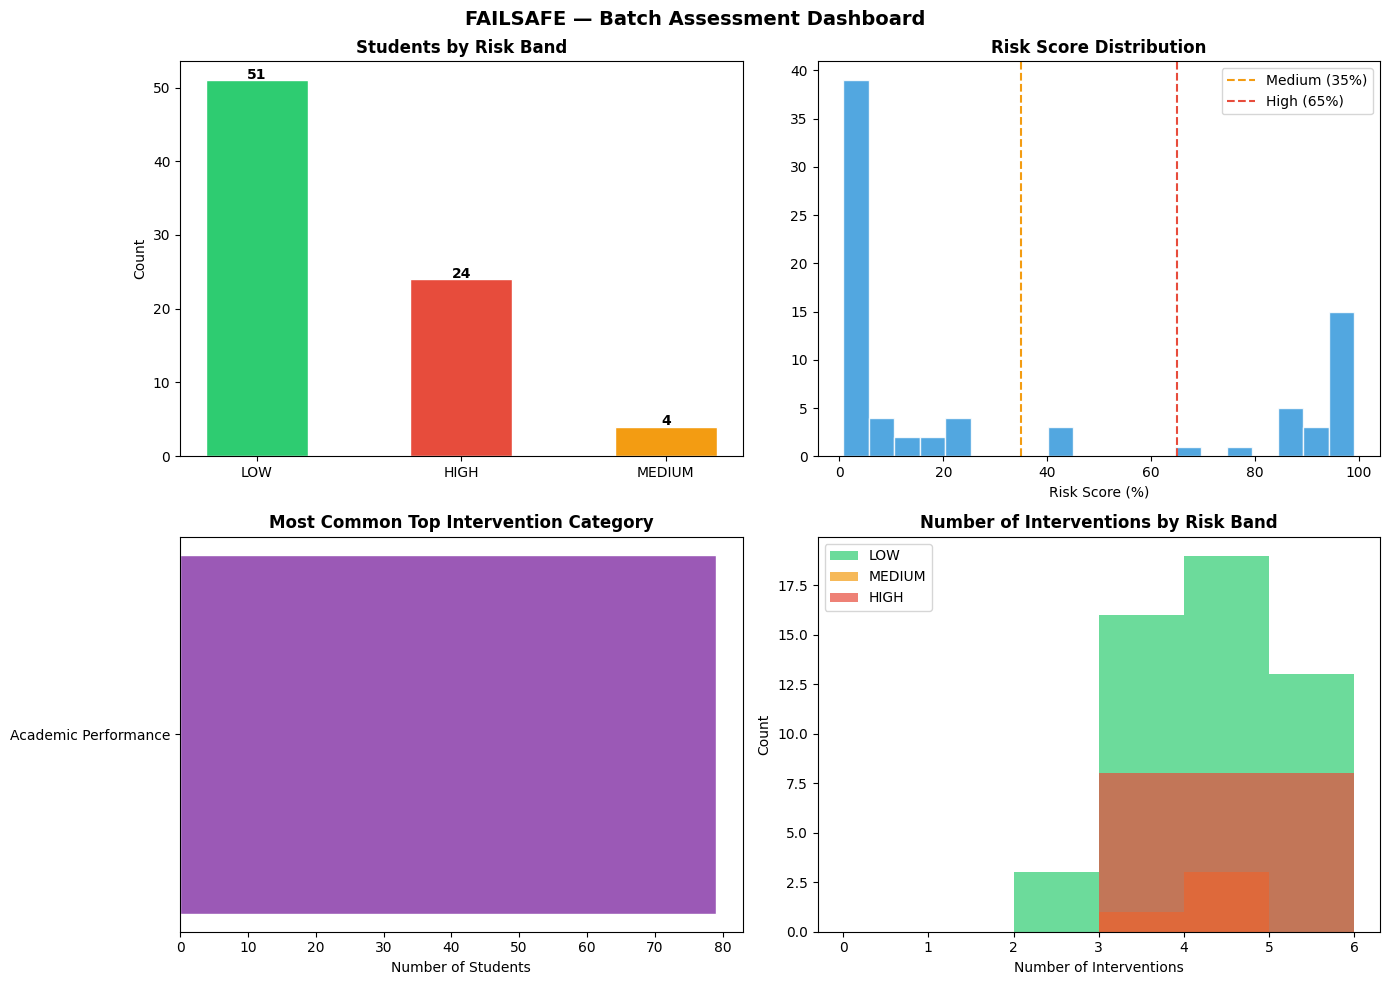

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_map = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'}

# 1. Risk band distribution
band_counts = batch_results['risk_band'].value_counts()
bars = axes[0, 0].bar(band_counts.index, band_counts.values,
                      color=[colors_map[b] for b in band_counts.index],
                      edgecolor='white', width=0.5)
axes[0, 0].set_title('Students by Risk Band', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for bar, val in zip(bars, band_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                    str(val), ha='center', fontweight='bold')

# 2. Risk score distribution
axes[0, 1].hist(batch_results['risk_score'], bins=20,
                color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(x=RISK_LOW * 100, color='#f39c12', linestyle='--',
                   label=f'Medium ({int(RISK_LOW*100)}%)')
axes[0, 1].axvline(x=RISK_HIGH * 100, color='#e74c3c', linestyle='--',
                   label=f'High ({int(RISK_HIGH*100)}%)')
axes[0, 1].set_title('Risk Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Risk Score (%)')
axes[0, 1].legend()

# 3. Top intervention categories
cat_counts = batch_results['top_category'].value_counts().head(8)
axes[1, 0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color='#9b59b6', edgecolor='white')
axes[1, 0].set_title('Most Common Top Intervention Category', fontweight='bold')
axes[1, 0].set_xlabel('Number of Students')

# 4. Interventions per risk band
for band, color in zip(['LOW', 'MEDIUM', 'HIGH'],
                        ['#2ecc71', '#f39c12', '#e74c3c']):
    subset = batch_results[batch_results['risk_band'] == band]['num_interventions']
    if len(subset) > 0:
        axes[1, 1].hist(subset, alpha=0.7, label=band,
                        color=color, bins=range(0, 7))
axes[1, 1].set_title('Number of Interventions by Risk Band', fontweight='bold')
axes[1, 1].set_xlabel('Number of Interventions')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.suptitle('FAILSAFE — Batch Assessment Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import os
os.makedirs('backend', exist_ok=True)

module_code = '''"""
FAILSAFE — Intervention Engine
intervention_engine.py

Imported by FastAPI. Uses Groq LLM to generate personalized
intervention plans. Falls back to rule-based text silently
on any Groq failure — no error surfaces to the user.
"""

import time
import logging
import pandas as pd
from typing import List, Dict, Any, Tuple

logger = logging.getLogger("failsafe.intervention")

# ── Groq config (override via environment variables in production) ──
import os
GROQ_API_KEY    = os.getenv("GROQ_API_KEY", "")
GROQ_MODEL      = os.getenv("GROQ_MODEL", "llama-3.3-70b-versatile")
GROQ_FALLBACK   = "llama-3.1-8b-instant"
GROQ_MAX_TOKENS = 500
GROQ_TIMEOUT    = 8

try:
    from groq import Groq
    _groq_client = Groq(api_key=GROQ_API_KEY) if GROQ_API_KEY else None
except Exception:
    _groq_client = None


INTERVENTION_RULES = {
    "absences"  : {"bad_when": "high", "threshold": 6,  "priority": 1, "category": "Attendance",          "intervention": "Student has high absences. Schedule an immediate one-on-one attendance review. Identify root cause and issue a warning if absences exceed 10."},
    "failures"  : {"bad_when": "high", "threshold": 1,  "priority": 1, "category": "Academic History",    "intervention": "Student has a history of past failures. Assign a dedicated mentor. Enroll in remedial support classes and set monthly HOD reviews."},
    "G2"        : {"bad_when": "low",  "threshold": 10, "priority": 1, "category": "Academic Performance", "intervention": "Student scored below passing in the second period. Arrange tutoring and review weak topics with the subject teacher."},
    "G1"        : {"bad_when": "low",  "threshold": 10, "priority": 2, "category": "Academic Performance", "intervention": "Student showed early struggle in the first period. Run a diagnostic assessment and pair with a peer study partner."},
    "studytime" : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Study Habits",         "intervention": "Student studies less than 2 hours per week. Introduce a structured timetable and recommend the study skills workshop."},
    "Dalc"      : {"bad_when": "high", "threshold": 3,  "priority": 1, "category": "Wellness",             "intervention": "Student has high weekday alcohol consumption. Refer to the counselling center immediately and coordinate with guardian."},
    "Walc"      : {"bad_when": "high", "threshold": 3,  "priority": 2, "category": "Wellness",             "intervention": "Student has elevated weekend alcohol consumption. Suggest a confidential wellness session and monitor Monday attendance."},
    "goout"     : {"bad_when": "high", "threshold": 4,  "priority": 2, "category": "Time Management",      "intervention": "Student spends significant time socializing. Discuss time management and help build a balanced weekly schedule."},
    "health"    : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Health Support",       "intervention": "Student reports poor health. Refer to the campus health center and explore academic accommodations."},
    "higher"    : {"bad_when": "low",  "threshold": 1,  "priority": 2, "category": "Motivation",           "intervention": "Student lacks higher education aspiration. Arrange career counselling and connect with inspiring alumni or mentors."},
    "internet"  : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Resource Access",      "intervention": "Student lacks home internet. Direct to campus Wi-Fi, computer labs, and printed materials."},
    "Medu"      : {"bad_when": "low",  "threshold": 2,  "priority": 3, "category": "Family Background",    "intervention": "Low maternal education background. Assign a faculty mentor and connect with first-generation student support."},
    "Fedu"      : {"bad_when": "low",  "threshold": 2,  "priority": 3, "category": "Family Background",    "intervention": "Low paternal education background. Ensure access to office hours and recommend peer tutoring."},
    "famrel"    : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Family & Wellbeing",   "intervention": "Poor family relationships reported. Refer to a counsellor and monitor for signs of stress in class."},
    "schoolsup" : {"bad_when": "low",  "threshold": 1,  "priority": 2, "category": "Academic Support",     "intervention": "Student receives no school support. Enroll in the academic support program and assign extra sessions."},
    "famsup"    : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Family Support",       "intervention": "No family educational support. Increase faculty check-ins and share progress with guardians."},
    "romantic"  : {"bad_when": "high", "threshold": 1,  "priority": 3, "category": "Personal Factors",     "intervention": "Romantic relationship may affect focus. Counsel sensitively on balancing personal and academic life."},
    "traveltime": {"bad_when": "high", "threshold": 3,  "priority": 3, "category": "Logistics",            "intervention": "Long daily commute. Explore accommodation options and consider favorable class scheduling."},
    "freetime"  : {"bad_when": "high", "threshold": 4,  "priority": 3, "category": "Time Management",      "intervention": "Excessive free time suggesting low engagement. Encourage joining academic clubs or project groups."},
    "paid"      : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Academic Support",     "intervention": "Not attending extra classes. Recommend free campus tutoring or peer study groups."},
    "activities": {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Engagement",           "intervention": "No extracurricular involvement. Encourage joining at least one club or sport."},
}


def get_risk_band(prob: float, low: float = 0.35, high: float = 0.65) -> str:
    if prob >= high:
        return "HIGH"
    elif prob >= low:
        return "MEDIUM"
    return "LOW"


def generate_rule_interventions(student_data: Dict, shap_values_dict: Dict, top_n: int = 5) -> List[Dict]:
    ranked = sorted(shap_values_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    interventions = []
    for feat, shap_val in ranked:
        if feat not in INTERVENTION_RULES:
            continue
        rule = INTERVENTION_RULES[feat]
        val  = student_data.get(feat)
        if val is None:
            continue
        is_risky = (rule["bad_when"] == "high" and val >= rule["threshold"]) or \\
                   (rule["bad_when"] == "low"  and val <  rule["threshold"])
        if is_risky or abs(shap_val) > 0.2:
            interventions.append({
                "feature": feat, "value": val, "shap": round(float(shap_val), 4),
                "priority": rule["priority"], "category": rule["category"],
                "intervention": rule["intervention"], "source": "rules",
            })
    interventions.sort(key=lambda x: (x["priority"], -abs(x["shap"])))
    return interventions


def _build_prompt(student_data, rule_interventions, risk_score, risk_band):
    factors = "\\n".join([f"  - {i[\'category\']} ({i[\'feature\']} = {i[\'value\']})"
                          for i in rule_interventions])
    rules   = "\\n".join([f"  [{i[\'category\']}]: {i[\'intervention\']}" for i in rule_interventions])
    return f"""You are an empathetic educational advisor helping faculty support an at-risk student.
Student situation: Risk Score {risk_score}% ({risk_band} risk)\nKey concerns:\n{factors}\nSuggested actions:\n{rules}
Rewrite as a single cohesive, empathetic plan. No bullet points. No mention of AI, scores, or models. Under 200 words. Focus on what faculty should DO."""


def generate_llm_intervention(student_data, rule_interventions, risk_score, risk_band) -> Tuple[str, str]:
    if not rule_interventions:
        return "No critical interventions needed at this time. Continue monitoring.", "rules"
    prompt = _build_prompt(student_data, rule_interventions, risk_score, risk_band)
    for attempt, groq_model in enumerate([GROQ_MODEL, GROQ_FALLBACK]):
        try:
            if _groq_client is None:
                raise RuntimeError("Groq client not initialized")
            response = _groq_client.chat.completions.create(
                model=groq_model, max_tokens=GROQ_MAX_TOKENS, timeout=GROQ_TIMEOUT,
                messages=[
                    {"role": "system", "content": "You are an empathetic educational advisor."},
                    {"role": "user",   "content": prompt}
                ]
            )
            text = response.choices[0].message.content.strip()
            if text and len(text) > 30:
                return text, "llm"
        except Exception as e:
            logger.warning(f"Groq attempt {attempt+1} failed ({groq_model}): {type(e).__name__}")
            if attempt == 0:
                time.sleep(0.5)
    fallback_text = " ".join([i["intervention"] for i in rule_interventions])
    return fallback_text, "rules"


def run_full_assessment(student_id, student_data, model, explainer, features,
                         threshold=0.45, use_llm=True) -> Dict:
    df_input   = pd.DataFrame([student_data])[features]
    prob       = float(model.predict_proba(df_input)[0][1])
    risk_score = round(prob * 100, 1)
    risk_band  = get_risk_band(prob)
    prediction = "AT-RISK" if prob >= threshold else "PASSING"
    sv         = explainer.shap_values(df_input)[0]
    shap_dict  = {feat: float(sv[i]) for i, feat in enumerate(features)}
    top_factors = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    rule_interventions = generate_rule_interventions(student_data, shap_dict)
    if use_llm:
        intervention_plan, plan_source = generate_llm_intervention(
            student_data, rule_interventions, risk_score, risk_band)
    else:
        intervention_plan = " ".join([r["intervention"] for r in rule_interventions])
        plan_source = "rules"
    return {
        "student_id": student_id, "risk_score": risk_score, "risk_band": risk_band,
        "prediction": prediction, "shap_values": shap_dict, "top_factors": top_factors,
        "rule_interventions": rule_interventions,
        "intervention_plan": intervention_plan,
        "plan_source": plan_source,
    }
'''

with open('backend/intervention_engine_groq.py', 'w') as f:
    f.write(module_code.strip())

print('Exported: backend/intervention_engine_groq.py')
print()
print('Usage in FastAPI:')
print('  from intervention_engine import run_full_assessment')
print()
print('Environment variable needed in production:')
print('  GROQ_API_KEY=your_key_here')

Exported: backend/intervention_engine_groq.py

Usage in FastAPI:
  from intervention_engine import run_full_assessment

Environment variable needed in production:
  GROQ_API_KEY=your_key_here
